Task 1: Load CIFAR-10, Display Samples, Class Distribution

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2794s 16us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


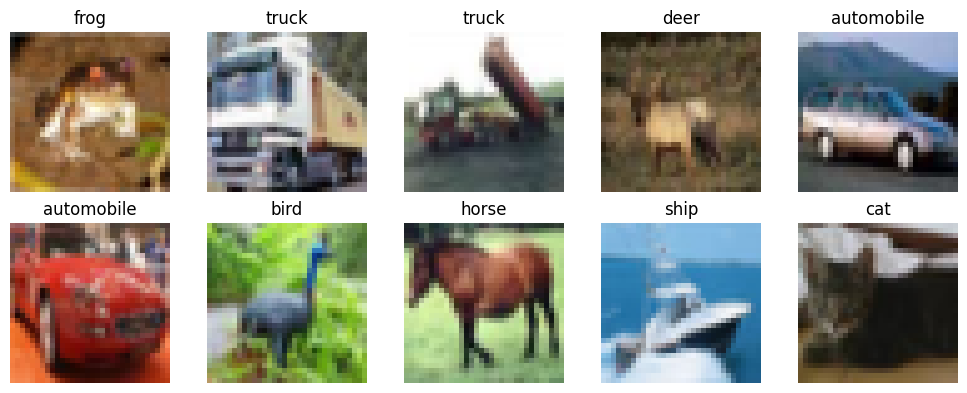

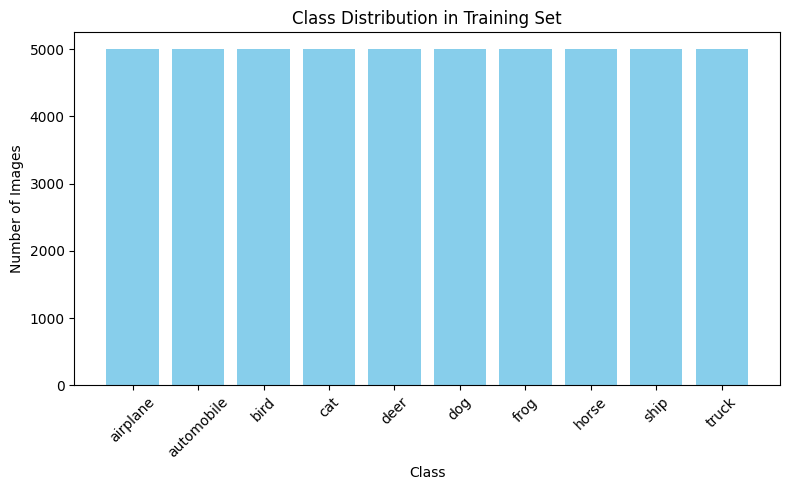

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150)
plt.show()
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar([class_names[i] for i in unique], counts, color='skyblue')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution in Training Set')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

Task 2: Convolution Layer with Different Kernel Sizes

In [2]:
from tensorflow.keras.layers import Conv2D, Input
from tensorflow.keras.models import Model

sample_img = np.expand_dims(x_train_norm[0], axis=0)

kernel_sizes = [3, 5, 7]
feature_map_sizes = {}

for k in kernel_sizes:
    inp = Input(shape=(32, 32, 3))
    conv = Conv2D(filters=8, kernel_size=k, strides=1, padding='valid')(inp)
    model = Model(inp, conv)
    output = model.predict(sample_img, verbose=0)
    feature_map_sizes[k] = output.shape
    print(f"Kernel {k}x{k} -> Feature map shape: {output.shape}")
N = 32
P = 0
S = 1
print("\nManual calculation (padding='valid', stride=1):")
for F in kernel_sizes:
    out_dim = (N - F + 2 * P) // S + 1
    print(f"Kernel {F}x{F} -> Output size: {out_dim}x{out_dim}")

Kernel 3x3 -> Feature map shape: (1, 30, 30, 8)
Kernel 5x5 -> Feature map shape: (1, 28, 28, 8)
Kernel 7x7 -> Feature map shape: (1, 26, 26, 8)

Manual calculation (padding='valid', stride=1):
Kernel 3x3 -> Output size: 30x30
Kernel 5x5 -> Output size: 28x28
Kernel 7x7 -> Output size: 26x26


Task 3: Stride and Padding Comparison

In [3]:
configs = [
    {'stride': 1, 'padding': 'valid'},
    {'stride': 2, 'padding': 'valid'},
    {'stride': 1, 'padding': 'same'},
    {'stride': 2, 'padding': 'same'},
]

print("Input size: 32x32, Kernel size: 3x3\n")

for cfg in configs:
    inp = Input(shape=(32, 32, 3))
    conv = Conv2D(filters=8, kernel_size=3, strides=cfg['stride'],
                  padding=cfg['padding'])(inp)
    model = Model(inp, conv)
    output = model.predict(sample_img, verbose=0)
    print(f"Stride={cfg['stride']}, Padding={cfg['padding']} "
          f"-> Output shape: {output.shape}")
def compute_output_size(N, F, P, S):
    return (N - F + 2 * P) // S + 1

print("\nManual calculations:")
N, F = 32, 3
print("Valid padding, stride 1:", compute_output_size(N, F, 0, 1))
print("Valid padding, stride 2:", compute_output_size(N, F, 0, 2))
print("Same padding, stride 1: 32 (output preserved)")
print("Same padding, stride 2: 16 (output halved)")

Input size: 32x32, Kernel size: 3x3

Stride=1, Padding=valid -> Output shape: (1, 30, 30, 8)


Stride=2, Padding=valid -> Output shape: (1, 15, 15, 8)
Stride=1, Padding=same -> Output shape: (1, 32, 32, 8)
Stride=2, Padding=same -> Output shape: (1, 16, 16, 8)

Manual calculations:
Valid padding, stride 1: 30
Valid padding, stride 2: 15
Same padding, stride 1: 32 (output preserved)
Same padding, stride 2: 16 (output halved)


Task 4: Feature Map Visualization

Feature maps shape: (1, 32, 32, 32)


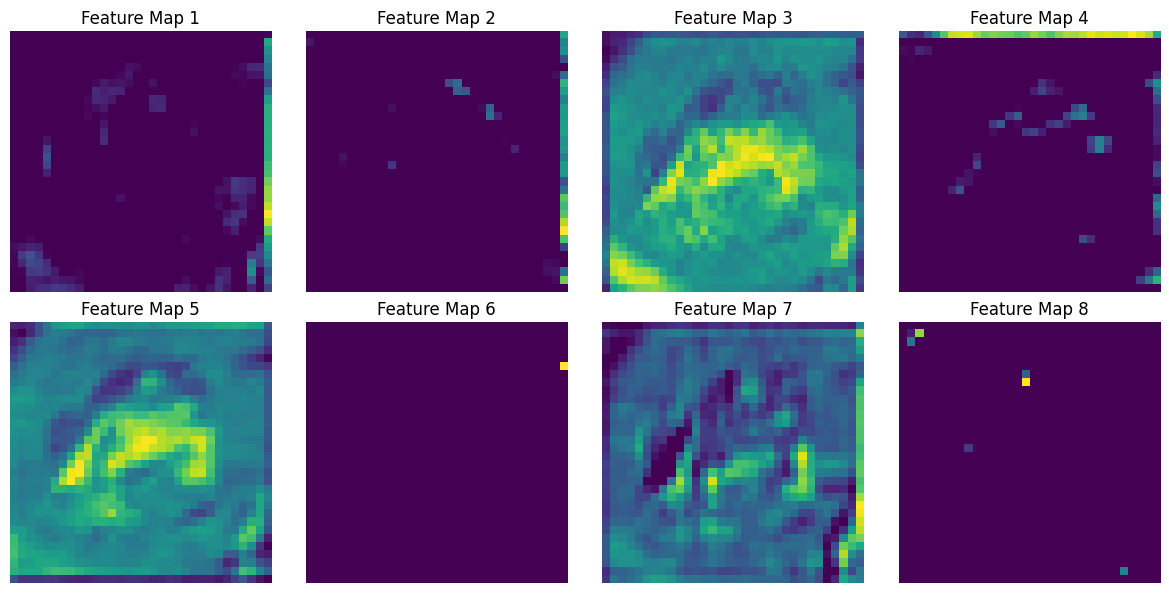

In [5]:
from tensorflow.keras.layers import Input, Conv2D
from tensorflow.keras.models import Sequential, Model

viz_model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same')
])

first_conv_output_model = Model(inputs=viz_model.inputs,
                                 outputs=viz_model.layers[0].output)

sample_img = np.expand_dims(x_train_norm[0], axis=0)
feature_maps = first_conv_output_model.predict(sample_img, verbose=0)

print("Feature maps shape:", feature_maps.shape)

n_maps = 8
plt.figure(figsize=(12, 6))
for i in range(n_maps):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='viridis')
    plt.title(f'Feature Map {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.savefig('feature_maps.png', dpi=150)
plt.show()

Task 5: Max Pooling vs Average Pooling

In [10]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import to_categorical
import numpy as np
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

def build_model(pool_type='max'):
    model = Sequential()
    model.add(Input(shape=(32, 32, 3)))
    model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
    if pool_type == 'max':
        model.add(MaxPooling2D((2, 2)))
    else:
        model.add(AveragePooling2D((2, 2)))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    if pool_type == 'max':
        model.add(MaxPooling2D((2, 2)))
    else:
        model.add(AveragePooling2D((2, 2)))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

sample_img = np.expand_dims(x_train_norm[0], axis=0)
max_model = build_model('max')
max_model.summary()

pool_output_model_max = Model(inputs=max_model.inputs, outputs=max_model.layers[1].output)
print("Max Pooling output shape after first pooling layer:")
print(pool_output_model_max.predict(sample_img, verbose=0).shape)

max_history = max_model.fit(x_train_norm, y_train_cat,
                             epochs=5,
                             batch_size=32,
                             validation_split=0.1,
                             verbose=1)

avg_model = build_model('avg')
avg_model.summary()

pool_output_model_avg = Model(inputs=avg_model.inputs, outputs=avg_model.layers[1].output)
print("\nAverage Pooling output shape after first pooling layer:")
print(pool_output_model_avg.predict(sample_img, verbose=0).shape)

avg_history = avg_model.fit(x_train_norm, y_train_cat,
                             epochs=5,
                             batch_size=32,
                             validation_split=0.1,
                             verbose=1)

max_test_loss, max_test_acc = max_model.evaluate(x_test_norm, y_test_cat, verbose=0)
avg_test_loss, avg_test_acc = avg_model.evaluate(x_test_norm, y_test_cat, verbose=0)

print(f"\nMax Pooling     -> Test Loss: {max_test_loss:.4f}, Test Accuracy: {max_test_acc:.4f}")
print(f"Average Pooling -> Test Loss: {avg_test_loss:.4f}, Test Accuracy: {avg_test_acc:.4f}")

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 16, 16, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 8, 8, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 282,250 (1.08 MB)

 Trainable params: 282,250 (1.08 MB)

 Non-trainable params: 0 (0.00 B)


Average Pooling output shape after first pooling layer:
(1, 16, 16, 32)
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 47ms/step - accuracy: 0.4522 - loss: 1.5295 - val_accuracy: 0.5446 - val_loss: 1.2642
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 64s 46ms/step - accuracy: 0.5818 - loss: 1.1888 - val_accuracy: 0.6240 - val_loss: 1.0762
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 43ms/step - accuracy: 0.6285 - loss: 1.0575 - val_accuracy: 0.6272 - val_loss: 1.0489
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 63s 45ms/step - accuracy: 0.6617 - loss: 0.9700 - val_accuracy: 0.6576 - val_loss: 1.0047
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 43ms/step - accuracy: 0.6810 - loss: 0.9069 - val_accuracy: 0.6918 - val_loss: 0.9127

Max Pooling     -> Test Loss: 0.9378, Test Accuracy: 0.6715
Average Pooling -> Test Loss: 0.9537, Test Accuracy: 0.6684


Task 6: Full CNN Architecture


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 56ms/step - accuracy: 0.4976 - loss: 1.3983 - val_accuracy: 0.5766 - val_loss: 1.1920
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 57ms/step - accuracy: 0.6420 - loss: 1.0206 - val_accuracy: 0.6642 - val_loss: 0.9653
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 77s 54ms/step - accuracy: 0.6899 - loss: 0.8818 - val_accuracy: 0.6766 - val_loss: 0.9371
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.7270 - loss: 0.7778 - val_accuracy: 0.6518 - val_loss: 1.0070
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.7554 - loss: 0.6989 - val_accuracy: 0.7064 - val_loss: 0.8798
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.7821 - loss: 0.6180 - val_accuracy: 0.7102 - val_loss: 0.8617
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.8082 - loss: 0.5434 - val_accuracy: 0.7152 - val_loss: 0.9029
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.8318 -

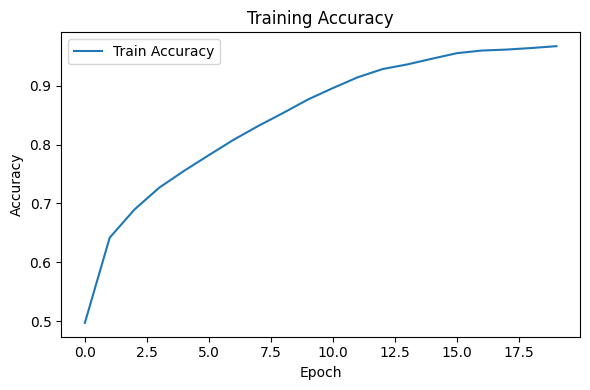

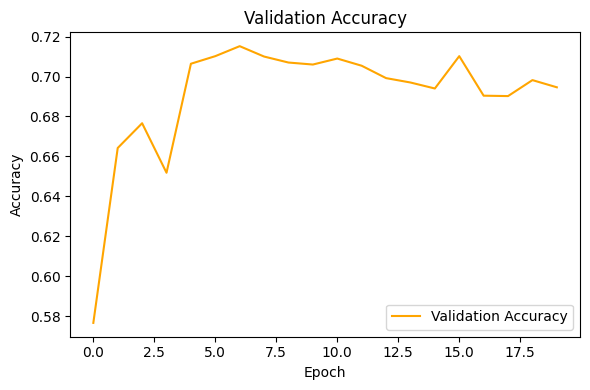

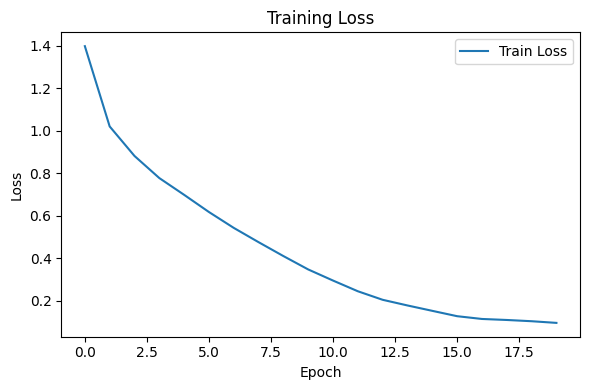

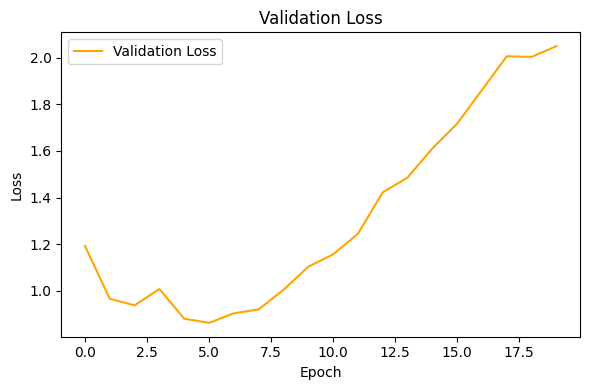

In [11]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)
model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
history = model.fit(x_train_norm, y_train_cat,
                     epochs=20,
                     batch_size=32,
                     validation_split=0.1,
                     verbose=1)
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('training_accuracy.png', dpi=150)
plt.show()
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('validation_accuracy.png', dpi=150)
plt.show()
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()
plt.figure(figsize=(6, 4))
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('validation_loss.png', dpi=150)
plt.show()

Task 7: Evaluation Metrics

Test Accuracy:  0.6785
Precision (macro): 0.6808
Recall (macro):    0.6785
F1-score (macro):  0.6775


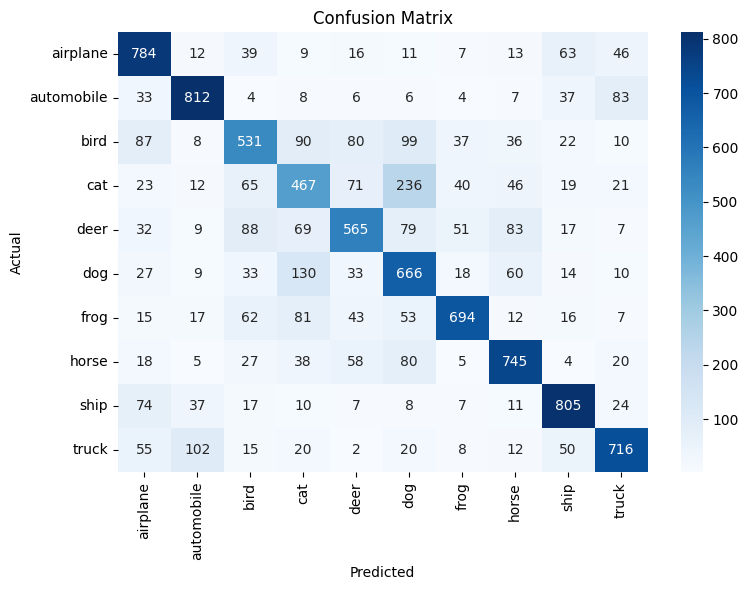


Classification Report:
              precision    recall  f1-score   support

    airplane       0.68      0.78      0.73      1000
  automobile       0.79      0.81      0.80      1000
        bird       0.60      0.53      0.56      1000
         cat       0.51      0.47      0.49      1000
        deer       0.64      0.56      0.60      1000
         dog       0.53      0.67      0.59      1000
        frog       0.80      0.69      0.74      1000
       horse       0.73      0.74      0.74      1000
        ship       0.77      0.81      0.79      1000
       truck       0.76      0.72      0.74      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000


Total trainable parameters: 545098


In [12]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

y_pred_probs = model.predict(x_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy:  {acc:.4f}")
print(f"Precision (macro): {prec:.4f}")
print(f"Recall (macro):    {rec:.4f}")
print(f"F1-score (macro):  {f1:.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))
print(f"\nTotal trainable parameters: {model.count_params()}")